  基於Python的鐵碳合金共析轉變與TTT曲線數值模擬系統  


請輸入想要觀察的等溫轉變溫度 (°C) [建議區間: 500 ~ 727]:  700



✅ 【輸入成功】: 成功設定等溫轉變溫度為 700.0°C，開始進行數值模擬...


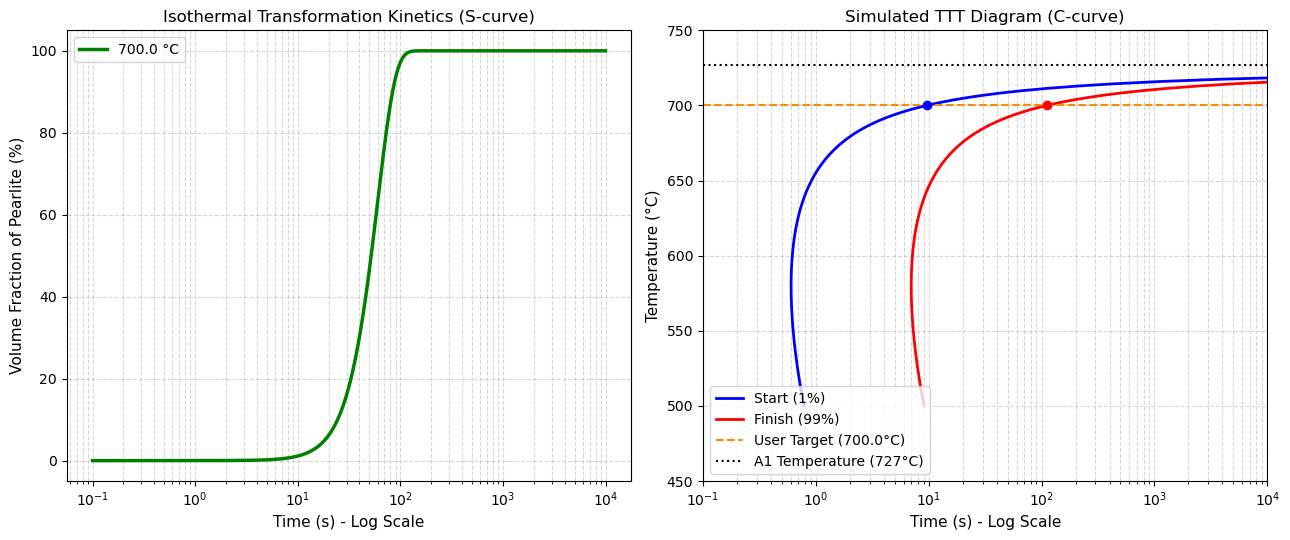

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# # 1. 基礎物理常數與函數定義
# ==============================================================================
R = 8.314          # 氣體常數 J/(mol·K)
D0 = 1.2e-4        # 擴散常數 m²/s
Q = 135000         # 活化能 J/mol
n_avrami = 2.5     # Avrami 指數
T_A1 = 727         # 共析轉變臨界溫度 (°C)

def get_k_from_temperature(T_celsius):
    """根據擴散係數與修正後的熱力學成核障礙，計算轉變速率常數 k"""
    T = T_celsius + 273.15  # 轉為絕對溫度
    T_limit = T_A1 + 273.15 # 臨界絕對溫度 (1000.15 K)
    
    # 修改防呆臨界點：嚴格大於 A1 才歸零；剛好等於時過冷度為 0，k 也會是 0
    if T > T_limit:
        return 0.0
        
    # (1) 擴散項 (Arrhenius)
    D = D0 * math.exp(-Q / (R * T))
    
    # (2) 驅動力項 (過冷度 ΔT)
    undercooling = T_limit - T
    
    # 防止分母為零：如果剛好等於 727 度，過冷度為 0，直接回傳 k = 0
    if undercooling == 0:
        return 0.0
    
    # (3) 熱力學成核障礙能修正
    nucleation_barrier = math.exp(-195000 / (T * undercooling))
    
    # 結合三項
    k = 1.2e7 * D * (undercooling**2) * nucleation_barrier
    return k

def calculate_time_from_avrami(X, k):
    """給定轉變率 X 與速率常數 k，反推所需時間 t"""
    if k <= 0:
        return float("inf") # 若 k 為 0，代表永無法發生轉變，時間為無限大
    return (-math.log(1 - X) / k) ** (1 / n_avrami)

# ==============================================================================
# # 2. 主程式控制核心（支援動態輸入與防呆顯示）
# ==============================================================================
def run_ttt_simulation():
    print("="*60)
    print("  基於Python的鐵碳合金共析轉變與TTT曲線數值模擬系統  ")
    print("="*60)
    
    # --- 互動輸入與動態公式/數值檢查機制 ---
    try:
        user_input = input(f"請輸入想要觀察的等溫轉變溫度 (°C) [建議區間: 500 ~ 727]: ").strip()
        
        # 支援基本數學公式解析
        if any(c.isalpha() for c in user_input if c not in ['+', '-', '*', '/', '.', '(', ')']):
            raise ValueError("輸入包含非法字元。")
        
        T_isothermal = float(eval(user_input))
        
    except Exception as e:
        print(f"\n❌ 【輸入錯誤】: 無法解析您的輸入內容，請輸入數字（例如: 727）。")
        return

    # --- 關鍵定值錯誤檢查 (修正後的邏輯) ---
    if T_isothermal > T_A1:
        print(f"\n❌ 【溫度錯誤】: 您輸入的溫度為 {T_isothermal}°C。")
        print(f"   💡 錯誤原因：該溫度已「大於」共析溫度 A1 ({T_A1}°C)，在此高溫下奧斯田鐵絕對無法發生轉變！")
        return
    elif T_isothermal == T_A1:
        print(f"\nℹ️ 【臨界平衡狀態】: 您輸入的溫度剛好是共析溫度 {T_A1}°C。")
        print(f"   💡 物理現象：此時系統處於熱力學平衡，過冷度為 0，反應驅動力為 0。")
        print(f"   💡 模擬結果：波來鐵轉變速率常數 k = 0，意味著需要「無限長的時間」才能開始轉變。")
    elif T_isothermal < 450:
        print(f"\n⚠️ 【範圍警告】: 您輸入的溫度為 {T_isothermal}°C。")
        print(f"   💡 警告原因：低於 450°C 已進入變韌鐵轉變區，本系統的波來鐵模型會失真。")
    else:
        print(f"\n✅ 【輸入成功】: 成功設定等溫轉變溫度為 {T_isothermal}°C，開始進行數值模擬...")

    # ==============================================================================
    # # 3. 繪圖與數據產出
    # ==============================================================================
    k_isothermal = get_k_from_temperature(T_isothermal)
    
    # 產生時間軸（對數間距，從 0.1 秒到 10000 秒）
    times = np.logspace(-1, 4, 1000)
    
    # 根據 Avrami 方程計算體積分率
    X_s_curve = 1 - np.exp(-k_isothermal * (times ** n_avrami))
    
    # 建立畫布
    plt.figure(figsize=(13, 5.5))
    
    # ---- 子圖 1：特定溫度下的 S 型相轉變曲線 ----
    plt.subplot(1, 2, 1)
    plt.plot(times, X_s_curve * 100, "g-", linewidth=2.5, label=f"{T_isothermal} °C")
    plt.xscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.xlabel("Time (s) - Log Scale", fontsize=11)
    plt.ylabel("Volume Fraction of Pearlite (%)", fontsize=11)
    plt.title(f"Isothermal Transformation Kinetics (S-curve)", fontsize=12)
    plt.legend(loc="upper left")
    
    # ---- 子圖 2：TTT 曲線模擬圖 (C 曲線) ----
    plt.subplot(1, 2, 2)
    
    # 設定背景要模擬的整體 TTT 溫度範圍 (500°C 到 725°C)
    celsius_temperatures = np.linspace(500, 725, 150)
    t_start_list = []
    t_finish_list = []
    valid_temperatures = []
    
    for C in celsius_temperatures:
        k_val = get_k_from_temperature(C)
        if k_val == 0:
            continue
        
        t_start = calculate_time_from_avrami(0.01, k_val)  
        t_finish = calculate_time_from_avrami(0.99, k_val) 
        
        t_start_list.append(t_start)
        t_finish_list.append(t_finish)
        valid_temperatures.append(C)
        
    # 繪製經典 C 曲線
    plt.plot(t_start_list, valid_temperatures, "b-", linewidth=2, label="Start (1%)")
    plt.plot(t_finish_list, valid_temperatures, "r-", linewidth=2, label="Finish (99%)")
    
    # 標註使用者動態輸入的等溫線
    plt.axhline(y=T_isothermal, color="darkorange", linestyle="--", linewidth=1.5, 
                label=f"User Target ({T_isothermal}°C)")
    # 標註 A1 共析溫度線
    plt.axhline(y=T_A1, color="k", linestyle=":", label=f"A1 Temperature ({T_A1}°C)")
    
    # 數值動態點標註（只有在時間不是無限大時才畫點，避免程式報錯）
    t_s_point = calculate_time_from_avrami(0.01, k_isothermal)
    t_f_point = calculate_time_from_avrami(0.99, k_isothermal)
    if t_s_point != float('inf') and t_s_point < 1e4:
        plt.plot(t_s_point, T_isothermal, 'bo')
        plt.plot(t_f_point, T_isothermal, 'ro')
    
    plt.xscale("log")
    plt.xlim(1e-1, 1e4)
    plt.ylim(450, 750)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.xlabel("Time (s) - Log Scale", fontsize=11)
    plt.ylabel("Temperature (°C)", fontsize=11)
    plt.title("Simulated TTT Diagram (C-curve)", fontsize=12)
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

# 執行模擬主程式
run_ttt_simulation()